


Zadanie 1

In [1]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


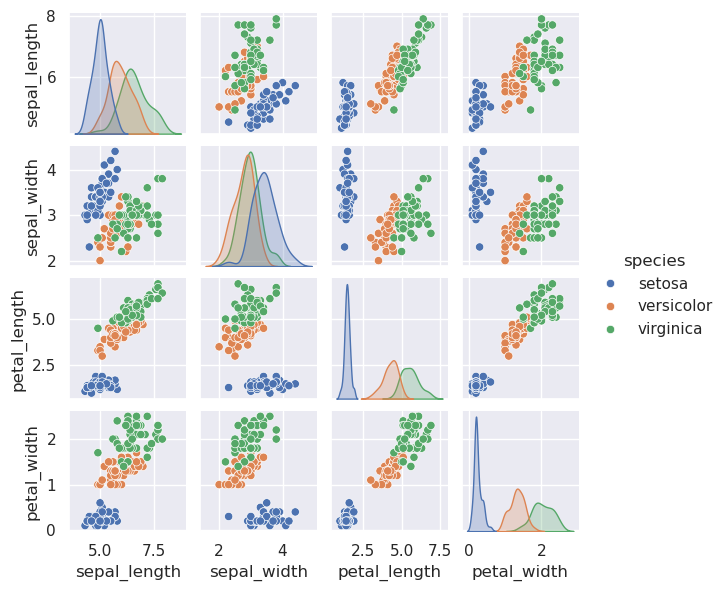

In [2]:
 %matplotlib inline
import seaborn as sns; sns.set()
sns.pairplot(iris, hue='species', height=1.5);

In [4]:
from sklearn.datasets import load_iris

In [5]:
iris = load_iris()
X = iris.data
y = iris.target

In [6]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [7]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=1) 
## the label of an unknown point is the same as the label of its closest training point

In [8]:
model.fit(X, y)

KNeighborsClassifier(n_neighbors=1)

In [9]:
y_model = model.predict(X)

In [10]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_model)

1.0

In [11]:
from sklearn.model_selection import train_test_split
# split the data with 50% in each set
X1, X2, y1, y2 = train_test_split(X, y, random_state=0,
                                  train_size=0.5)

# fit the model on one set of data
model.fit(X1, y1)

# evaluate the model on the second set of data
y2_model = model.predict(X2)
accuracy_score(y2, y2_model)


0.9066666666666666

In [12]:
y2_model = model.fit(X1, y1).predict(X2)
y1_model = model.fit(X2, y2).predict(X1)
accuracy_score(y1, y1_model), accuracy_score(y2, y2_model)

(0.96, 0.9066666666666666)

In [13]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 1.        ])

In [14]:
from sklearn.model_selection import LeaveOneOut
scores = cross_val_score(model, X, y, cv=LeaveOneOut())
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [15]:
scores.shape

(150,)

In [16]:
scores.mean()

0.96





Zadanie 2

In [1]:
import numpy as np
def make_data(N, err=1.0, rseed=1):
    # randomly sample the data
    rng = np.random.RandomState(rseed)
    X = rng.rand(N,1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y

In [2]:
make_data(10)

(array([[1.73907352e-01],
        [5.18867376e-01],
        [1.30815988e-08],
        [9.14049845e-02],
        [2.15372915e-02],
        [8.52641608e-03],
        [3.46928663e-02],
        [1.19412216e-01],
        [1.57424429e-01],
        [2.90323473e-01]]),
 array([ 8.09394226,  7.62293801,  0.3190404 ,  4.52610529,  3.23418063,
        -1.27448719,  2.25328463,  5.05831427,  7.24913423,  6.33813112]))

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

In [37]:
X, y = make_data(40)

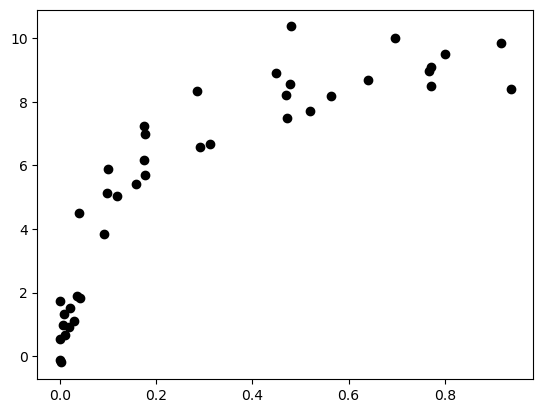

In [38]:
plt.scatter(X, y, color='black')

In [27]:
X_test = np.linspace(-0.1, 1.1, 500)

In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def PolynomialRegression(degree=2, **kwargs):
    return make_pipeline(PolynomialFeatures(degree),
                         LinearRegression(**kwargs))

In [29]:
model= PolynomialRegression(1).fit(X, y)    

In [30]:
X_test = np.linspace(-0.1, 1.1, 500)[:, None]

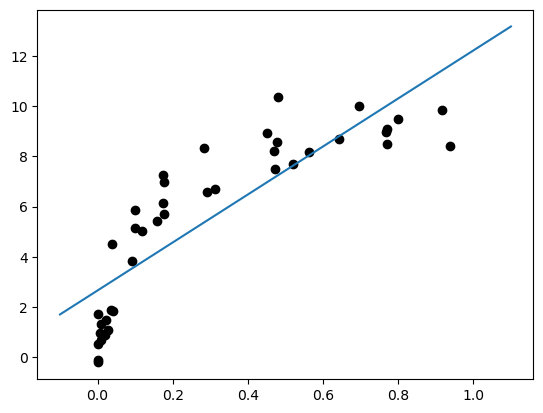

In [31]:
y_test=model.predict(X_test)

plt.plot(X_test.ravel(), y_test )
plt.scatter(X, y, color='black')

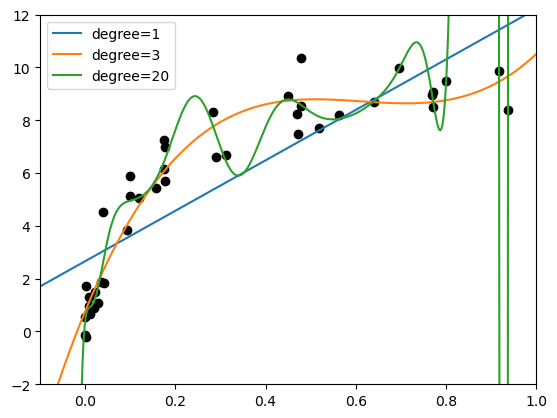

In [39]:
plt.scatter(X.ravel(), y, color='black')
axis = plt.axis()
for degree in [1, 3, 20]:
    y_test = PolynomialRegression(degree).fit(X, y).predict(X_test)
    plt.plot(X_test.ravel(), y_test, label='degree={0}'.format(degree))
plt.xlim(-0.1, 1.0)
plt.ylim(-2, 12)
plt.legend(loc='best');

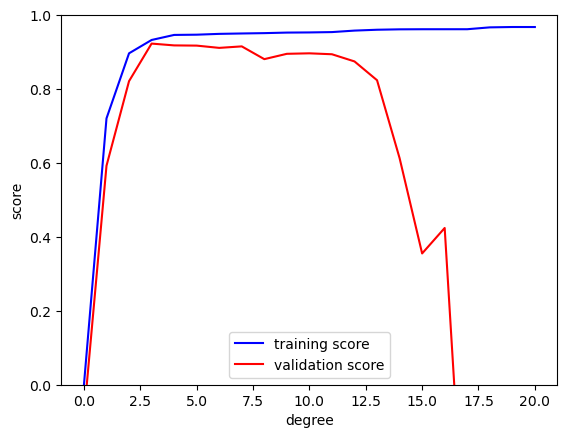

In [40]:
from sklearn.model_selection import validation_curve
degree = np.arange(0, 21)
train_score, val_score = validation_curve(
    PolynomialRegression(), X, y,
    param_name='polynomialfeatures__degree',    
    param_range=degree, cv=7)  ## cv - cross validation

plt.plot(degree, np.median(train_score, 1),
         color='blue', label='training score')
plt.plot(degree, np.median(val_score, 1),
         color='red', label='validation score')
plt.legend(loc='best')
plt.ylim(0, 1)
plt.xlabel('degree')
plt.ylabel('score');

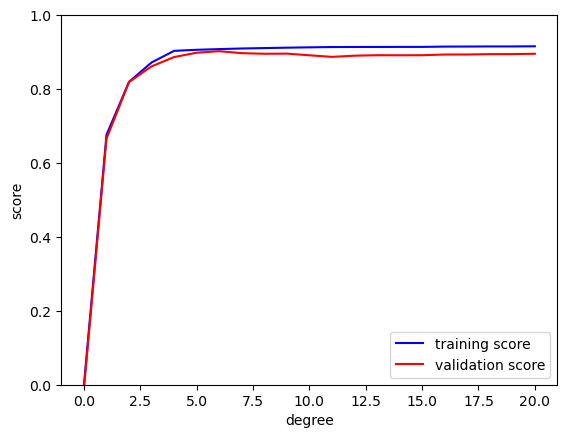

In [41]:
X2, y2 = make_data(200)

from sklearn.model_selection import validation_curve
degree = np.arange(0, 21)
train_score, val_score = validation_curve(
    PolynomialRegression(), X2, y2,
    param_name='polynomialfeatures__degree',    
    param_range=degree, cv=7)  ## cv - cross validation

plt.plot(degree, np.median(train_score, 1),
         color='blue', label='training score')
plt.plot(degree, np.median(val_score, 1),
         color='red', label='validation score')
plt.legend(loc='best')
plt.ylim(0, 1)
plt.xlabel('degree')
plt.ylabel('score');

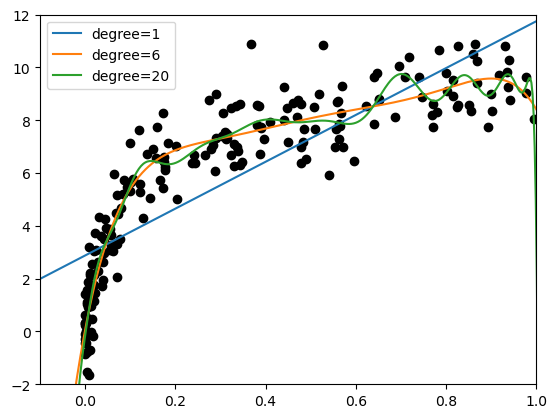

In [43]:
plt.scatter(X2.ravel(), y2, color='black')
axis = plt.axis()
for degree in [1, 6, 20]:
    y_test = PolynomialRegression(degree).fit(X2, y2).predict(X_test)
    plt.plot(X_test.ravel(), y_test, label='degree={0}'.format(degree))
plt.xlim(-0.1, 1.0)
plt.ylim(-2, 12)
plt.legend(loc='best');

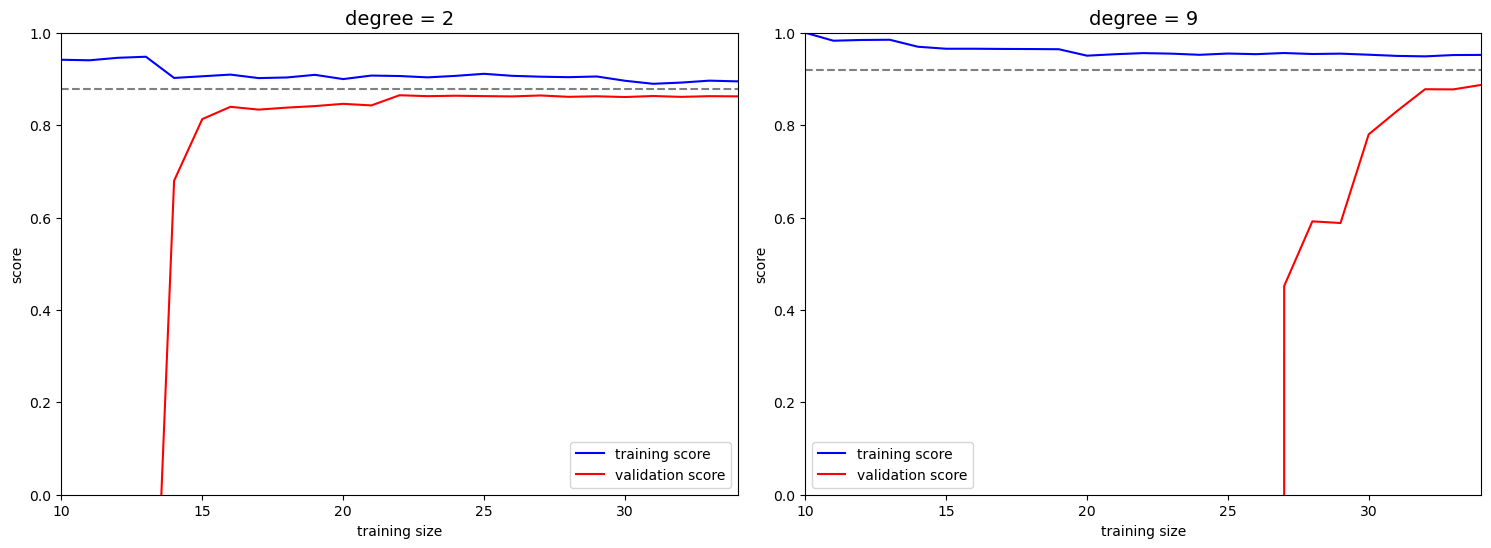

In [49]:
from sklearn.model_selection import learning_curve

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for i, degree in enumerate([2, 9]):
    N, train_lc, val_lc = learning_curve(
        PolynomialRegression(degree), X, y, cv=7,
        train_sizes=np.linspace(0.3, 1, 25))

    ax[i].plot(N, np.mean(train_lc, 1),
               color='blue', label='training score')
    ax[i].plot(N, np.mean(val_lc, 1),
               color='red', label='validation score')
    ax[i].hlines(np.mean([train_lc[-1], val_lc[-1]]), N[0],
                 N[-1], color='gray', linestyle='dashed')

    ax[i].set_ylim(0, 1)
    ax[i].set_xlim(N[0], N[-1])
    ax[i].set_xlabel('training size')
    ax[i].set_ylabel('score')
    ax[i].set_title('degree = {0}'.format(degree), size=14)
    ax[i].legend(loc='best')



Zadanie 3

In [51]:
data = [
    {'cena': 850000, 'pokoje': 4, 'okolica': 'Bronowice'},
    {'cena': 700000, 'pokoje': 3, 'okolica': 'Debniki'},
    {'cena': 650000, 'pokoje': 3, 'okolica': 'Stare Miasto'},
    {'cena': 600000, 'pokoje': 2, 'okolica': 'Pradnik'}
]

In [52]:
from sklearn.feature_extraction import DictVectorizer
vec = DictVectorizer(sparse=False, dtype=int)
vec.fit_transform(data)

array([[850000,      1,      0,      0,      0,      4],
       [700000,      0,      1,      0,      0,      3],
       [650000,      0,      0,      0,      1,      3],
       [600000,      0,      0,      1,      0,      2]])

In [53]:
vec.get_feature_names_out()

array(['cena', 'okolica=Bronowice', 'okolica=Debniki', 'okolica=Pradnik',
       'okolica=Stare Miasto', 'pokoje'], dtype=object)

In [54]:
vec = DictVectorizer(sparse=True, dtype=int)
vec.fit_transform(data)

<4x6 sparse matrix of type '<class 'numpy.int64'>'
	with 12 stored elements in Compressed Sparse Row format>

Zadanie 4

In [60]:
sample = ['problem of evil',
          'evil queen',
          'horizon problem',
          'evil is evil']

In [61]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
X = vec.fit_transform(sample)
X

<4x6 sparse matrix of type '<class 'numpy.int64'>'
	with 9 stored elements in Compressed Sparse Row format>

In [63]:
import pandas as pd
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,evil,horizon,is,of,problem,queen
0,1,0,0,1,1,0
1,1,0,0,0,0,1
2,0,1,0,0,1,0
3,2,0,1,0,0,0


Zadanie 5

In [65]:
from numpy import nan
X = np.array([[ nan, 0,   3  ],
              [ 3,   7,   9  ],
              [ 3,   5,   2  ],
              [ 4,   nan, 6  ],
              [ 8,   8,   1  ]])

In [67]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='mean')
X2 = imp.fit_transform(X)
X2

array([[4.5, 0. , 3. ],
       [3. , 7. , 9. ],
       [3. , 5. , 2. ],
       [4. , 5. , 6. ],
       [8. , 8. , 1. ]])

In [68]:
(3+3+4+8)/4

4.5